# 

# Report

2026-02-04 by Sam Utzinger

A total of 12,325 courses were scraped and 6151 were not duplicated over semsters. 41 contained "AI" related terms and I deamed only 19 of those actaully teach about ai. 

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import argparse
import re

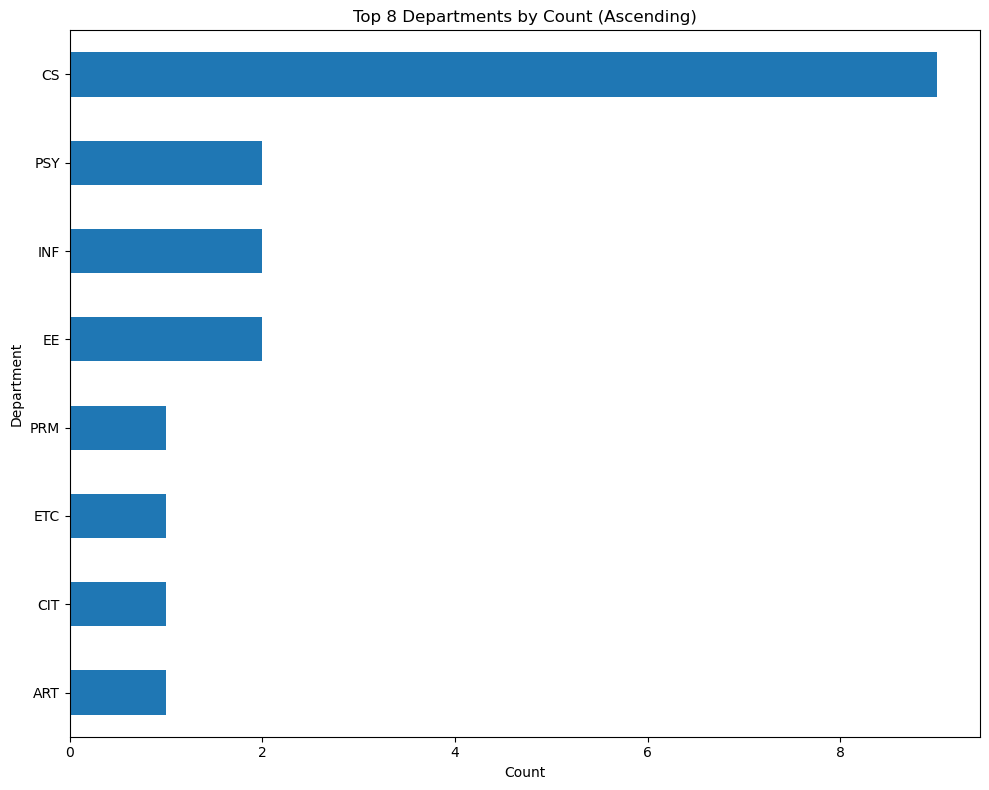

  Subject  Count
0      CS      9
1      EE      2
2     INF      2
3     PSY      2
4     ART      1
5     CIT      1
6     ETC      1
7     PRM      1


In [25]:

input = r"C:\Users\samut\Desktop\DataSciClub\Scraping\data\handmade_nau_courses_ai.csv"
top = 20

df = pd.read_csv(input)
counts = df["subject"].value_counts().sort_values(ascending=True)
if top and top > 0:
    counts = counts.tail(top)

plt.figure(figsize=(10, 8))
counts.plot(kind="barh")
plt.xlabel("Count")
plt.ylabel("Department")
plt.title(f"Top {len(counts)} Departments by Count (Ascending)")
plt.tight_layout()
plt.show()

created_table = {"Subject": ["CS", "EE", "INF", "PSY", "ART", "CIT", "ETC", "PRM"],
                 "Count": [9, 2, 2, 2, 1, 1, 1, 1]}
df_table = pd.DataFrame(created_table)
print(df_table)



Saved plot to level_split.png


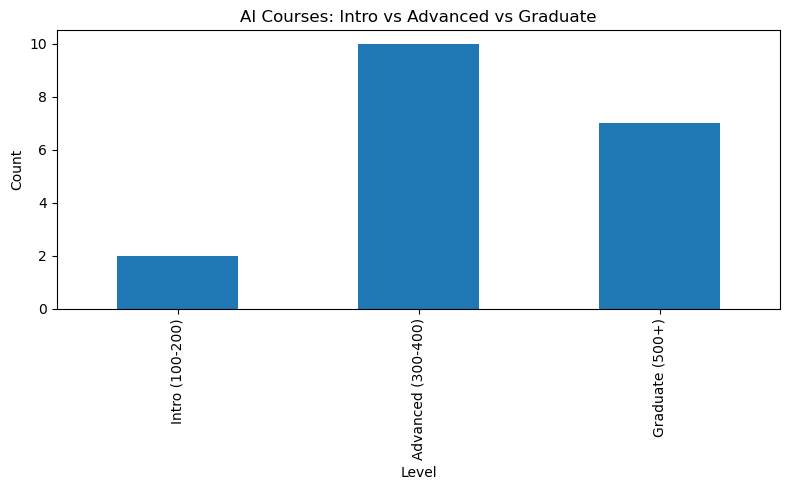

In [19]:
COURSE_NUM_RE = re.compile(r"(\d{3})")


def extract_course_number(row: pd.Series) -> int | None:
    course_display = str(row.get("course_display", "")).strip()
    if not course_display:
        return None
    # Use only the left side of " - " and remove any trailing letters (e.g., 470H -> 470).
    left = course_display.split(" - ", 1)[0]
    match = COURSE_NUM_RE.search(left)
    return int(match.group(1)) if match else None


def level_bucket(course_num: int | None) -> str:
    if course_num is None:
        return "Unknown"
    if 100 <= course_num <= 299:
        return "Intro (100-200)"
    if 300 <= course_num <= 499:
        return "Advanced (300-400)"
    if 500 <= course_num <= 799:
        return "Graduate (500+)"
    return "Unknown"


input_csv = r"c:\Users\samut\Desktop\DataSciClub\Scraping\data\handmade_nau_courses_ai.csv"
output_png = "level_split.png"

df = pd.read_csv(input_csv)
df["course_num"] = df.apply(extract_course_number, axis=1)
df["level"] = df["course_num"].apply(level_bucket)

counts = df["level"].value_counts().reindex(
    ["Intro (100-200)", "Advanced (300-400)", "Graduate (500+)"],
    fill_value=0,
)

plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.xlabel("Level")
plt.ylabel("Count")
plt.title("AI Courses: Intro vs Advanced vs Graduate")
plt.tight_layout()
plt.savefig(output_png, dpi=150)
print(f"Saved plot to {output_png}")


                                 Subject  Count
0              Technical AI/ML (methods)      9
1         Applied AI/ML (domain/project)      5
2          AI literacy / ethics / impact      3
3  AI-adjacent (robotics/generative art)      1
4     Generative AI / learning analytics      1


<Figure size 800x500 with 0 Axes>

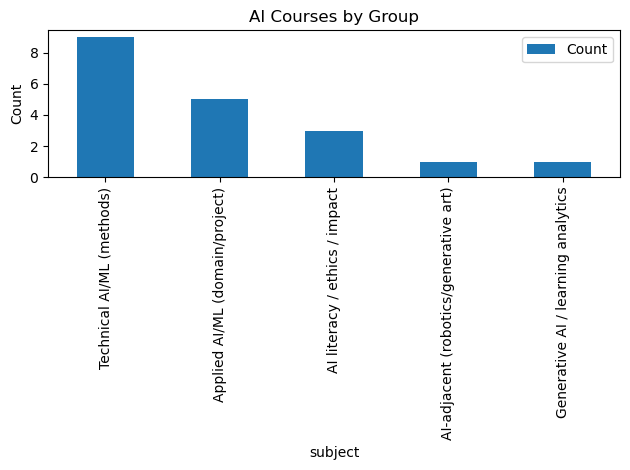

In [27]:
created_table = {"Subject": ["Technical AI/ML (methods)", "Applied AI/ML (domain/project)", "AI literacy / ethics / impact", "AI-adjacent (robotics/generative art)", "Generative AI / learning analytics"],
                 "Count": [9, 5, 3, 1, 1]}
df_table = pd.DataFrame(created_table)
print(df_table)

plt.figure(figsize=(8, 5))
df_table.plot(x="Subject", y="Count", kind="bar")
plt.xlabel("subject")
plt.ylabel("Count")
plt.title("AI Courses by Group")
plt.tight_layout()
plt.show()
